Epoch: 0 Loss: 0.21670452820349997
Epoch: 100 Loss: 0.0823751632477243
Epoch: 200 Loss: 0.061056873830322066
Epoch: 300 Loss: 0.05431839579490682
Epoch: 400 Loss: 0.05212019689994556
Epoch: 500 Loss: 0.051391433174210535
Epoch: 600 Loss: 0.051147728026981774
Epoch: 700 Loss: 0.05106584067005718
Epoch: 800 Loss: 0.05103825162504514
Epoch: 900 Loss: 0.05102894221313528


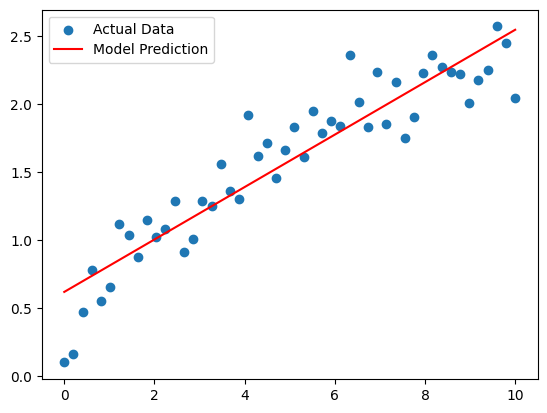

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Creating dataset
X = np.linspace(0,10,50).reshape(-1,1)

noise = np.random.normal(0,0.2,size=(50,1))
y = np.log(X+1) + noise

# Hidden layer size
hidden_units = 3

# Initialize parameters
W1 = np.random.uniform(-1,1,(1,hidden_units))
b1 = np.zeros((1,hidden_units))

W2 = np.random.uniform(-1,1,(hidden_units,1))
b2 = np.zeros((1,1))

# Activation function (ReLU)
def activation(z):
    return np.maximum(0,z)

def activation_slope(z):
    return (z>0).astype(float)

learning_rate = 0.01
epochs = 1000

for epoch in range(epochs):

    # Forward pass
    z1 = X @ W1 + b1
    h = activation(z1)
    y_hat = h @ W2 + b2

    # Loss
    error = y - y_hat
    loss = np.mean(error**2)

    # Backpropagation
    dl_dy = -2*error/len(X)

    dW2 = h.T @ dl_dy
    db2 = np.sum(dl_dy,axis=0,keepdims=True)

    dl_dh = dl_dy @ W2.T
    dl_dz1 = dl_dh * activation_slope(z1)

    dW1 = X.T @ dl_dz1
    db1 = np.sum(dl_dz1,axis=0,keepdims=True)

    # Update parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 100 == 0:
        print("Epoch:",epoch,"Loss:",loss)

# Final prediction
z1 = X @ W1 + b1
h = activation(z1)
y_pred = h @ W2 + b2

# Plot
plt.scatter(X,y,label="Actual Data")
plt.plot(X,y_pred,color='red',label="Model Prediction")
plt.legend()
plt.show()